#### Load the Dataset

In [16]:
%store -r X_train_scaled
%store -r X_test_scaled
%store -r X_scaled
%store -r y_train
%store -r y_test
%store -r y_dataset
%store -r X_train

#### Libraries

In [17]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import MinMaxScaler

#### Random Forest Algorithm with normal Fit

In [18]:
'''
param_grid = {
    'max_depth': [2, 3, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20], 
    'min_samples_leaf': [5, 10, 20, 100, 200, 300],
    'n_estimators': [10, 25, 50, 100, 200, 300],
}

random_forest = RandomForestClassifier(random_state=42)

# GridSearchCV 
grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, scoring='accuracy')
 
# Fit
grid_search.fit(X_train_scaled, y_train)

# Best parameters & mean cross-validated score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best Parameters: {best_params}')
print(f'Best Mean Cross-Validated Score: {best_score}')

random_forest = RandomForestClassifier(random_state=42,
                                       max_depth=best_params['max_depth'],
                                       min_samples_split=best_params['min_samples_split'],
                                       min_samples_leaf=best_params['min_samples_leaf'],
                                       n_estimators=best_params['n_estimators'])

# Convert the target variable to a 1D array using ravel()
y_train_array = y_train.values.ravel()

# Fit the model
random_forest.fit(X_train_scaled, y_train_array)
'''

"\nparam_grid = {\n    'max_depth': [2, 3, 5, 10, 20, 30],\n    'min_samples_split': [2, 5, 10, 20], \n    'min_samples_leaf': [5, 10, 20, 100, 200, 300],\n    'n_estimators': [10, 25, 50, 100, 200, 300],\n}\n\nrandom_forest = RandomForestClassifier(random_state=42)\n\n# GridSearchCV \ngrid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, scoring='accuracy')\n \n# Fit\ngrid_search.fit(X_train_scaled, y_train)\n\n# Best parameters & mean cross-validated score\nbest_params = grid_search.best_params_\nbest_score = grid_search.best_score_\n\nprint(f'Best Parameters: {best_params}')\nprint(f'Best Mean Cross-Validated Score: {best_score}')\n\nrandom_forest = RandomForestClassifier(random_state=42,\n                                       max_depth=best_params['max_depth'],\n                                       min_samples_split=best_params['min_samples_split'],\n                                       min_samples_leaf=best_params['min_samples_leaf'],\n             

In [19]:
random_forest = RandomForestClassifier(
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

# Convert the target variable to a 1D array using ravel()
y_train_array = y_train.values.ravel()

# Fit the model
random_forest.fit(X_train_scaled, y_train_array)

%store random_forest

Stored 'random_forest' (RandomForestClassifier)


#### Importance of Features

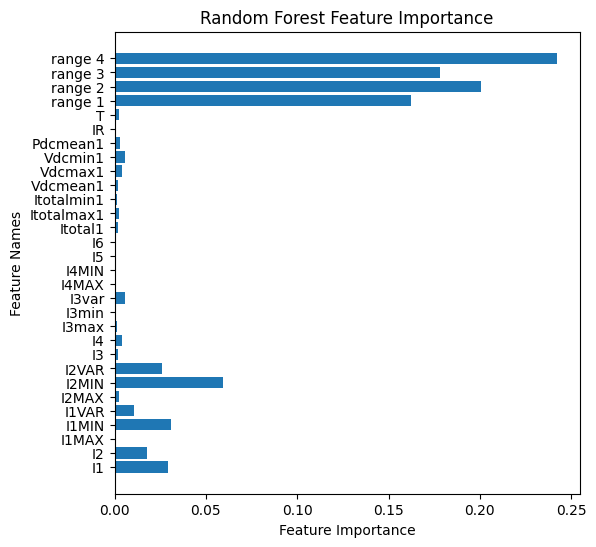

In [20]:
feature_importances = random_forest.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(6, 6))  

plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature Names')
plt.title('Random Forest Feature Importance')
plt.show()

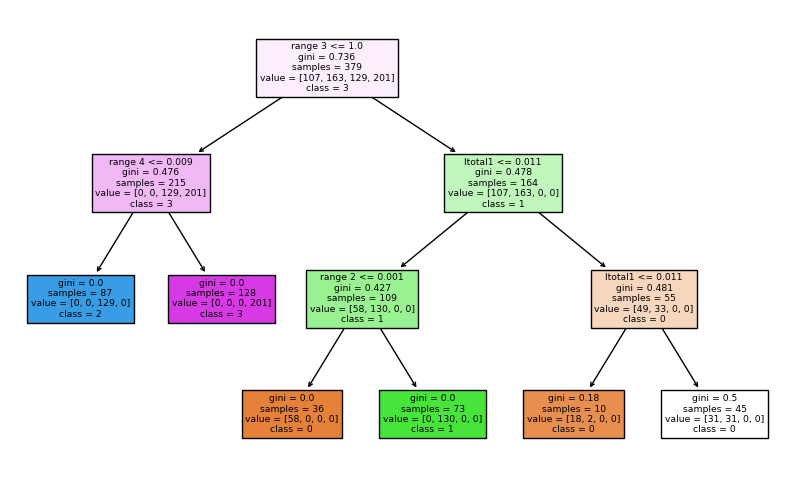

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))
plot_tree(random_forest.estimators_[1], feature_names=X_train.columns, class_names=['0', '1', '2', '3'], filled=True)
plt.show()

#### Evaluation on Training Data

In [22]:
y_train_pred_proba = random_forest.predict_proba(X_train_scaled)

# Precision
precision_train = precision_score(y_train, random_forest.predict(X_train_scaled), average='weighted')

# Recall
recall_train = recall_score(y_train, random_forest.predict(X_train_scaled), average='weighted')

# F1-Score
f1_train = f1_score(y_train, random_forest.predict(X_train_scaled), average='weighted')

# Classification Accuracy
accuracy_train = accuracy_score(y_train, random_forest.predict(X_train_scaled))

# Log Loss
log_loss_value_train = log_loss(y_train, y_train_pred_proba)

# Confusion Matrix
conf_matrix_train = confusion_matrix(y_train, random_forest.predict(X_train_scaled))

# AROC Curve
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba, multi_class='ovr', labels=random_forest.classes_)

# Evaluation Metrics
print(f'Training Confusion Matrix:\n{conf_matrix_train}')
print()
print(f'Training Area Under the ROC Curve (AROC): {roc_auc_train}')
print(f'Training Accuracy: {accuracy_train}')
print(f'Training F1-Score: {f1_train}')
print(f'Training Precision: {precision_train}')
print(f'Training Recall: {recall_train}')
print(f'Training Log Loss: {log_loss_value_train}')

Training Confusion Matrix:
[[100   0   0   0]
 [  0 153   0   0]
 [  0   0 149   0]
 [  0   0   0 198]]

Training Area Under the ROC Curve (AROC): 1.0
Training Accuracy: 1.0
Training F1-Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training Log Loss: 0.452681423669151


#### Evaluation on Test Data

In [23]:
y_test_pred = random_forest.predict(X_test_scaled)
#y_test_proba = random_forest.predict_proba(X_test_scaled)[:, 1]  
y_test_pred_proba = random_forest.predict_proba(X_test_scaled)

# Precision
precision = precision_score(y_test, y_test_pred, average='weighted')
%store precision

# Recall
recall = recall_score(y_test, y_test_pred, average='weighted')
%store recall

# F1-Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
%store f1

# Classification Accuracy
accuracy = accuracy_score(y_test, y_test_pred)
%store accuracy

# Log Loss
log_loss_value_test = log_loss(y_test, y_test_pred_proba, labels=random_forest.classes_)
%store log_loss_value_test

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
%store conf_matrix

# AROC Curve
roc_auc = roc_auc_score(y_test, y_test_pred_proba, multi_class='ovr', labels=random_forest.classes_)
%store roc_auc

# Evaluation Metrics
print(f'\nTest Confusion Matrix:\n{conf_matrix}')
print(f'\nTest Area Under the ROC Curve (AROC): {roc_auc}')
print(f'Test Accuracy: {accuracy}')
print(f'Test F1-Score: {f1}')
print(f'Test Precision: {precision}')
print(f'Test Recall: {recall}')
print(f'Test Log Loss: {log_loss_value_test}')

Stored 'precision' (float64)
Stored 'recall' (float64)
Stored 'f1' (float64)
Stored 'accuracy' (float64)
Stored 'log_loss_value_test' (float64)
Stored 'conf_matrix' (ndarray)
Stored 'roc_auc' (float64)

Test Confusion Matrix:
[[25  0  0  0]
 [ 4 21  0  0]
 [ 0  9 16  0]
 [ 0  0  0 25]]

Test Area Under the ROC Curve (AROC): 0.9872
Test Accuracy: 0.87
Test F1-Score: 0.8675125236100846
Test Precision: 0.8905172413793103
Test Recall: 0.87
Test Log Loss: 0.6398300752764272


### Plot Results
#### Confusion Matrix

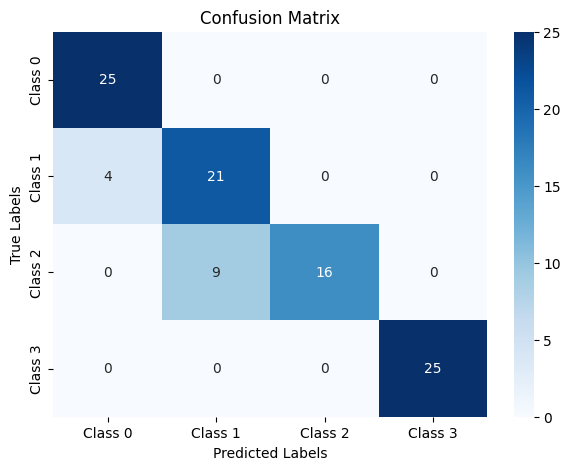

In [24]:
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix 
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Receiver Operating Characteristic (ROC) Curve

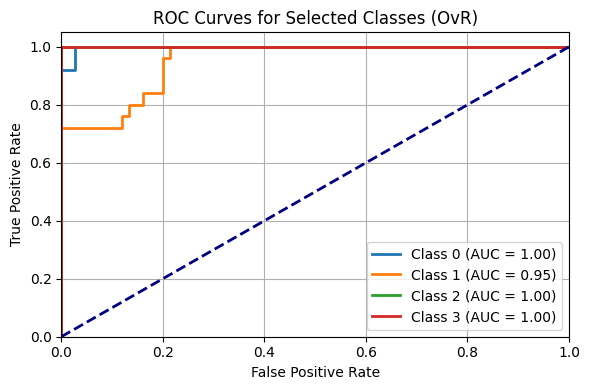

In [25]:
selected_classes = [0, 1, 2, 3]
plt.figure(figsize=(6, 4))

for class_label in selected_classes:
    y_test_binary = (y_test == class_label).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_proba[:, class_label])
    roc_auc = auc(fpr, tpr)
    
    # Customize κάθε κλάση
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})', 
             color=plt.cm.get_cmap('tab10')(class_label), linestyle='-', linewidth=2)

# Plot the diagonal line 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Selected Classes (OvR)')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()


#### Precision, Recall, F1 Score, Accuracy

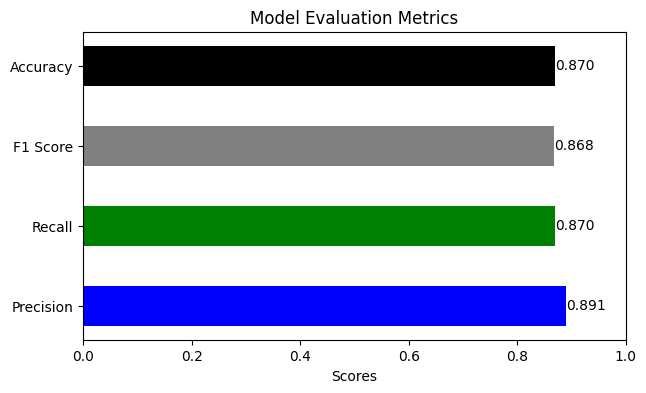

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [precision, recall, f1, accuracy]
bar_width = 0.5

# Plot horizontal bars
bars = ax.barh(metrics, scores, height=bar_width, color=['blue', 'green', 'grey', 'black'])

# Display actual values 
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

ax.set_xlim(0, 1)
plt.show()

#### Log Loss

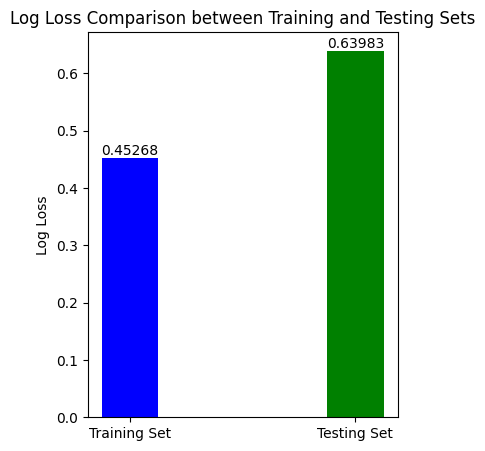

In [27]:
# Plotting
fig, ax = plt.subplots(figsize=(4, 5))

log_loss_values = [log_loss_value_train, log_loss_value_test]
labels = ['Training Set', 'Testing Set']

bar_width = 0.25

ax.bar(labels, log_loss_values, color=['blue', 'green'], width=bar_width)

for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.5f}',
             va='bottom', ha='center', color='black')

ax.set_ylabel('Log Loss')
ax.set_title('Log Loss Comparison between Training and Testing Sets')

plt.show()

#### Random Forest Algorithm with 5fold Cross Validation

In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_5cross = RandomForestClassifier(
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']

cv_results = cross_validate(rf_5cross, X_scaled, y_dataset, cv=kf, scoring=scoring_metrics, return_train_score=False)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]}")
    print(f"Precision: {cv_results['test_precision_weighted'][fold-1]}")
    print(f"Recall: {cv_results['test_recall_weighted'][fold-1]}")
    print(f"F1 Score: {cv_results['test_f1_weighted'][fold-1]}")
    print(f"Log Loss: {abs(np.mean(cv_results['test_neg_log_loss'][fold-1]))}")
    print(f"ROC AUC: {cv_results['test_roc_auc_ovo_weighted'][fold-1]}")
    print("--"*100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'neg_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")

Fold 1 Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Log Loss: 0.4806270776499541
ROC AUC: 1.0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.9928571428571429
Precision: 0.993045112781955
Recall: 0.9928571428571429
F1 Score: 0.9928287740628167
Log Loss: 0.490005108558571
ROC AUC: 1.0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.9857142857142858
Precision: 0.9867724867724869
Recall: 0.9857142857142858
F1 Score: 0.9857657967032968
Log Loss: 0.49955200856199583
ROC AUC: 0.9991861471861472
-----------------------------------------------------------------------------------------------------------------------------

##### Plot the Cross Valdation Results

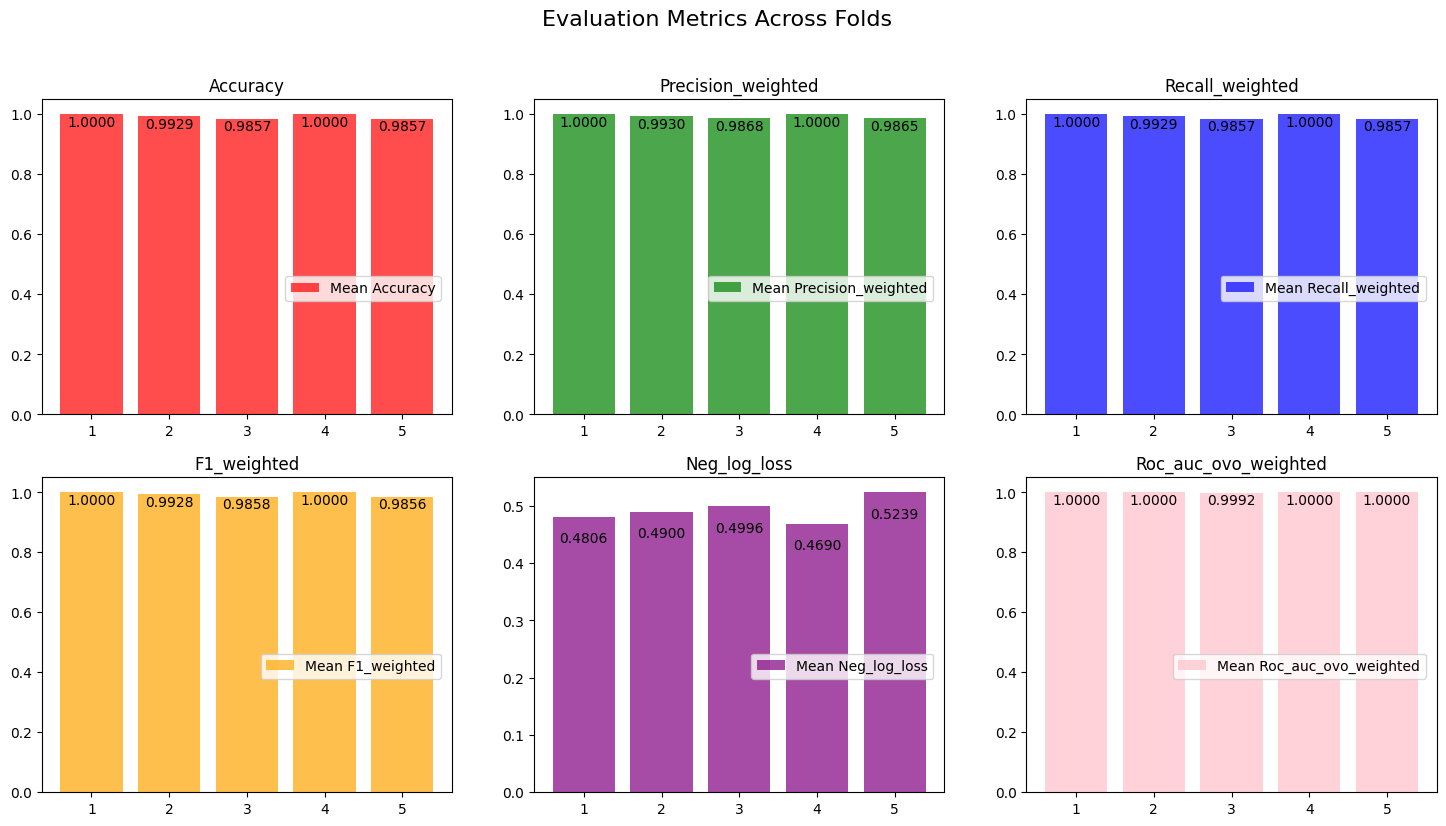

In [30]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function για τς τιμές μέσα στις μπάρες
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink']  

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 3
    col = idx % 3

    if metric == 'neg_log_loss':
        metric_values = np.abs(cv_results[f'test_{metric}'])
    else:
        metric_values = cv_results[f'test_{metric}']

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

if len(metrics_to_plot) < 6:
    fig.delaxes(axes[-1, -1])

plt.subplots_adjust(hspace=0.2)
plt.show()